# Ligand-Receptor Interaction Correlation (LRIC)


In this tutorial, we demonstrates how cross pair-correlation function **(cross-PCF)** and Ligand–Receptor Interaction Correlation **(LRIC)** can be used to study spatial organisation and potential cell–cell communication in spatial transcriptomics data.
<br>

**Cross-PCF** measures whether two cell types occur near one another more or less frequently than expected given the observed tissue structure. We retain the measured cell locations and compare the observed cell-type arrangement with a random-labelling null model, this separates cell-type co-localisation from effects caused by tissue boundaries, holes, fragmentation, or other irregular spatial geometry.
<br>

**LRIC** extends this idea by incorporating ligand and receptor expression. Rather than counting every neighbouring cell pair equally, it weights **sender cells by ligand expression** and **receiver cells by receptor expression**. The resulting distance-dependent score identifies ligand–receptor pairs whose expression is spatially co-enriched beyond what would be expected from tissue architecture and cell-type composition alone.
<br>

LRIC is inspired by the cross pair-correlation function of [Bull et al., 2024](https://www.biorxiv.org/content/10.1101/2024.12.06.627195), adapted here to weight cells by ligand/receptor expression and to use a null model that handles real, irregularly shaped tissue sections robustly.

<img src="LRIC_summary.png" width=1000 />

#### Interpreting cross-PCF and LRIC results

Both methods return a distance-dependent statistic, `(g(r))`, calculated for spatial distance bins centred around a given distance (r).
<br>

g(r) > 1 indicates enrichment at distance r. <br>
g(r) ≈ 1 indicates no enrichment beyond the null expectation. <br>
g(r) < 1 indicates depletion or spatial avoidance.

## Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
from pathlib import Path
from itertools import islice
import copy
from scipy import sparse
import os

import liana as li



import warnings
warnings.filterwarnings("ignore")

## Load and Normalize Data

To demonstrate the LRIC in practice, we will apply it to a spatial transcriptomics dataset from [A molecularly defined and spatially resolved cell atlas of the whole mouse brain(Nature, 2023)](https://www.nature.com/articles/s41586-023-06808-9); [WB_MERFISH_animal2_coronal](https://cellxgene.cziscience.com/collections/0cca8620-8dee-45d0-aef5-23f032a5cf09).

The dataset was generated using **MERFISH** technique, which enables highly multiplexed single-molecule RNA imaging with subcellular spatial resolution. This dataset profiles the expression of more than **1,000** genes across roughly **10 million cells** in the adult **mouse brain**.

In [2]:
file_path  = "data/MERFISH_mouse_brain/WB_MERFISH_animal2_coronal.h5ad"
backup_url = "https://datasets.cellxgene.cziscience.com/93c3bb97-ea05-4ee0-a760-a1508cd04612.h5ad"

adata = sc.read(file_path) if os.path.exists(file_path) else sc.read(file_path, backup_url=backup_url)

# Subset to one brain section
adata = adata[adata.obs["brain_section_label"] == "C57BL6J-2.039"]
# The dataset indexes vars by Ensembl ID; switch to gene symbols for LR lookup
adata.var_names = adata.var["gene_name"]

# Basic QC
sc.pp.filter_cells(adata, min_genes=10)
sc.pp.filter_genes(adata, min_cells=3)

# Normalise (keep raw counts in a layer); LRIC will use normalised log1p values
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

# Spatial coordinates are in µm (MERFISH physical units)
print(adata)

AnnData object with n_obs × n_vars = 51539 × 1120
    obs: 'donor_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'disease_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'assay_ontology_term_id', 'suspension_type', 'cluster_id_transfer', 'subclass_transfer', 'cluster_confidence_score', 'subclass_confidence_score', 'high_quality_transfer', 'major_brain_region', 'ccf_region_name', 'brain_section_label', 'tissue_type', 'is_primary_data', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'n_genes'
    var: 'gene_name', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'n_cells'
    uns: 'citation', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'log1p'
    obsm: 'X_CCF', 'X_spatial_coords', 'X_umap'
    layers: 'counts'


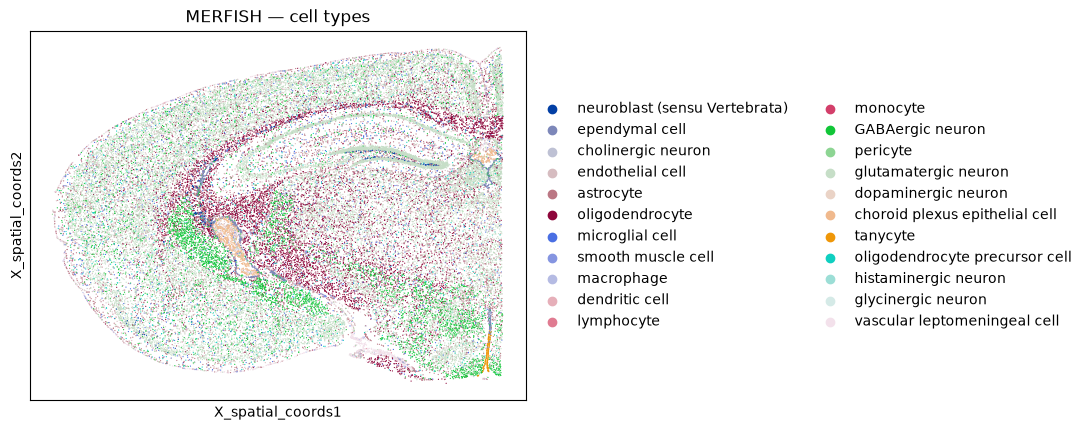

In [3]:
sc.pl.embedding(
    adata, basis="X_spatial_coords",
    color="cell_type", s=3, title="MERFISH — cell types"
)

In [4]:
## Set variables 
cell_type_key = "cell_type"
spatial_key="X_spatial_coords"
region_key = "major_brain_region"

## Ligand–Receptor Database (mouse)

In [5]:
resource = li.rs.select_resource('mouseconsensus')
print(f"{len(resource)} LR pairs in resource")
resource.head(5)

3989 LR pairs in resource


,ligand,receptor
31371,Dll1,Notch1
31372,Dll1,Notch2
31373,Dll1,Notch4
31374,Dll1,Notch3
31375,Nrg2,Erbb2_Erbb3


### Choose the right parameters
All distance parameters are in the same units as the spatial coordinates **µm** for this MERFISH dataset. <br>
**radius_step** = step between bin inner edges (e.g. 20-25 µm, the typical upper bound of the diameter of generic cells; though this might vary a lot depending on the tissue and cell types!). <br>
**annulus_width** = radial width of each annulus ring. <br>
Setting `annulus_width = radius_step` ensures bins are non-overlapping and tile the full range without gaps. <br>
**max_radius** = inner edge of the last (widest) bin; the outer edge extends to `max_radius + annulus_width`. <br>

In [6]:
annulus_width = 20
radius_step = 20

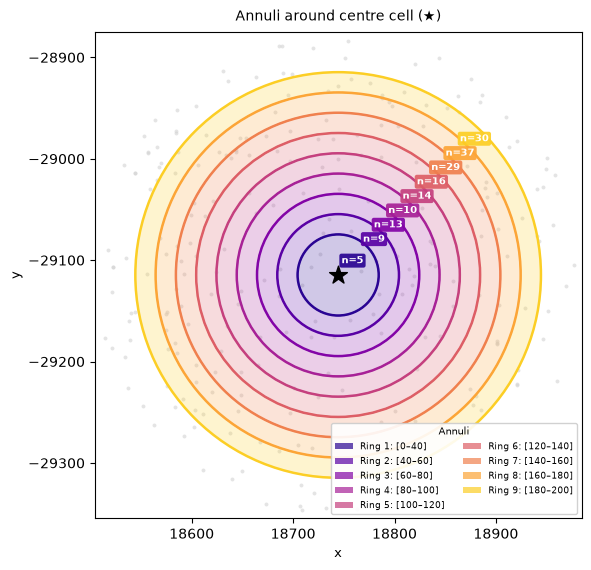

In [7]:
li.pl.annulus_plot(
    adata,
    spatial_key="X_spatial_coords",
    annulus_width=annulus_width,
    radius_step=radius_step,
    n_rings=9,
    seed=5,
    figure_size= (6, 6))

Note that, by default (`extend_first_annulus=True`), the innermost `[0, radius_step)` contact band is merged **into the first annulus**, which therefore spans `[0, radius_step + annulus_width)` and starts at radius 0. Distances are measured from each **focal cell's centroid**, so cell centroids cannot lie closer than ~one cell diameter; the innermost band is otherwise a thin, near-empty, high-variance bin. Merging it folds genuine cell–cell contact pairs into the first bin instead of discarding them. Set `extend_first_annulus=False` to keep the first ring at `[radius_step, radius_step + annulus_width)`.

## Ranking interactions using AUC–log2 score


`g(r)` is a curve per interaction. To compare many interactions, we apply **AUC–log2 score**: the (mean) area under `log2 g(r)`. 

- **`log2`** puts enrichment and depletion on one symmetric axis: `0` = null,
  `+1` = 2× enriched, `−1` = 2× depleted.
- **Integrate over radius.** The score is the area under `log2 g(r)`,

$$\text{score} = \frac{1}{\Delta r}\int \log_2 g(r)\,dr$$

Integrating (rather than taking the peak) makes the score reflect the *whole*
curve: a pair that is consistently enriched across radii accumulates a large
area, while a single noisy bin contributes only a thin sliver. Dividing by the
radial span `Δr` turns the area into a **mean log2 fold-change**, comparable
across samples and radius grids (use `normalize=False` to keep the raw integral
when you only rank within one sample). By default the integral is taken over a
**short-range window** (`max_dist`),

**Read it as:** `> 0` co-enriched, `< 0` depleted, `≈ 0` random. The magnitude
is a fold-change (`2**score`, so `1` ≈ 2×).

In [13]:
HALF_ANNULUS = annulus_width / 2         # inner-edge radius -> annulus centre
G_FLOOR      = 0.05                      # floor on g(r) before log2 (keeps empty/depleted bins finite)

def _log2g(curve):
    """log2 g(r), g floored at G_FLOOR to keep empty/depleted bins finite."""
    return np.log2(np.maximum(np.asarray(curve, float), G_FLOOR))
def _iter_features(adata, modality):
    """Yield (feature_key, g(r) profile) for every feature in adata.uns[modality]."""
    d = adata.uns[modality]; r = np.asarray(d["radii"], float)
    if modality == "cross_pcf":                       # symmetric: emit each unordered pair once
        seen = set()
        for k, c in d["results"].items():
            if frozenset(k) not in seen and not seen.add(frozenset(k)):
                yield k, np.asarray(c, float).ravel()
    elif modality == "lric_ag":
        M = np.asarray(d["lric"], float); M = M if M.shape[0] == r.size else M.T
        for j, lr in enumerate(d["pair_names"]): yield lr, M[:, j]
    elif modality == "lric_ct":
        for k, a in d["results"].items():
            A = np.asarray(a, float); A = A if A.shape[0] == r.size else A.T
            for j, lr in enumerate(d["pair_names"]): yield (k, lr), A[:, j]
    else:
        raise ValueError(f"unknown modality {modality!r}")

def _feature_label(feat, modality):
    if modality == "cross_pcf": return f"{feat[0]} ↔ {feat[1]}"
    if modality == "lric_ag":   return feat.replace("^", " → ")
    (a, b), lr = feat;          return f"{a} → {b}\n{lr.replace('^', ' → ')}"

def auc_log2_score(adata, modality, max_dist=None, normalize=True, min_bins=3):
    """(Mean) area under log2 g(r) — one signed score per interaction.

    >0 co-enriched, <0 depleted, 0 = random. `modality` is one of
    "cross_pcf"/"lric_ag"/"lric_ct" or any iterable of them; multiple ->
    one long frame with a `modality` column.

    max_dist  : integrate only over r < max_dist (radius units); None -> all r.
    normalize : True  -> integral / radial span = mean log2 FC (comparable across samples);
                False -> raw integral (log2 * radius units; single-sample).
    min_bins  : drop pairs with < this many finite log2 g(r) in the window
                (support gate; catches expr_prop-masked & degenerate pairs).
    """
    mods = [modality] if isinstance(modality, str) else list(modality)
    rows = []
    for mod in mods:
        radii = np.asarray(adata.uns[mod]["radii"], float)
        x_all = radii + HALF_ANNULUS
        win = radii < max_dist if max_dist is not None else np.ones(radii.size, bool)
        for key, curve in _iter_features(adata, mod):
            y = _log2g(np.asarray(curve, float))
            m = win & np.isfinite(y) & np.isfinite(x_all)
            if m.sum() < min_bins:                       # support gate
                continue
            x, yv = x_all[m], y[m]
            span = x.max() - x.min()
            area = np.trapezoid(yv, x)
            rows.append({
                "modality": mod,
                "feature": key,
                "label": _feature_label(key, mod).replace("\n", "  "),
                "score": area / span if (normalize and span > 0) else area,
            })
    cols = ["modality", "feature", "label", "score"]
    if not rows:
        return pd.DataFrame(columns=cols)
    return pd.DataFrame(rows, columns=cols).sort_values("score", ascending=False, ignore_index=True)

#### Plotting functions 

In [14]:
from matplotlib.colors import LinearSegmentedColormap, to_rgb

C_TOP, C_BOT, C_REST = "#009E73", "#D55E00", "#BBBBBB"

def _clean(ax):
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_visible(False)
def _grey(ax, xy, s): ax.scatter(*xy.T, s=s * .35, c="#E9E9E9", linewidths=0, rasterized=True)
def _seq_cmap(base):
    """Clean single-hue light→dark ramp: low expr = light tint (hue kept, distinct from the
    grey background), high expr = dark and pops."""
    c = np.array(to_rgb(base)); lo = 1 - 0.25 * (1 - c)
    return LinearSegmentedColormap.from_list("seq", [lo, c, 0.5 * c])

def _gene_vals(adata, name, layer=None, complex_sep="_"):
    """1-D expression for a gene, or the min-subunit value of a complex."""
    cols = [name] if name in adata.var_names else [g for g in name.split(complex_sep) if g in adata.var_names]
    if not cols: raise KeyError(f"{name!r} not in adata.var_names")
    X = adata[:, cols].layers[layer] if layer else adata[:, cols].X
    X = X.toarray() if sparse.issparse(X) else np.asarray(X)
    return X.min(1).ravel()

def _panel_types(ax, coords, types, a, b, s):
    _grey(ax, coords[~np.isin(types, (a, b))], s)
    for ct, col in ((a, C_TOP), (b, C_BOT)):
        m = types == ct
        ax.scatter(*coords[m].T, s=s, c=col, linewidths=0, label=f"{ct}  (n={int(m.sum())})", rasterized=True)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.02), fontsize=8,
              markerscale=2, frameon=False); _clean(ax)

def _panel_expr(ax, coords, vals, title, cmap, s, focus=None, clip=(2, 98), floor=0.0):
    keep = np.ones(len(vals), bool) if focus is None else np.asarray(focus)
    expr = keep & (vals > floor)                            # only real expressers get colour;
    _grey(ax, coords[~expr], s)                             # non-expressing (<=floor) + off-type = grey
    cx, cv = coords[expr], vals[expr]
    if cv.size:
        lo, hi = np.nanpercentile(cv, clip)                 # contrast spans the expressers, not the zeros
        o = np.argsort(cv)                                  # high-expressing cells on top
        sc = ax.scatter(*cx[o].T, c=cv[o], s=s * 1.3, cmap=cmap, vmin=lo, vmax=max(hi, lo + 1e-9),
                        linewidths=0, rasterized=True)
        cb = ax.figure.colorbar(sc, ax=ax, shrink=.55, aspect=28, pad=.01)
        cb.outline.set_visible(False); cb.ax.tick_params(labelsize=7, length=2)
    ax.set_title(title, fontsize=11); _clean(ax)

def plot_interaction(adata, modality, feature, *, groupby=None, spatial_key="spatial", lr_sep="^",
                     layer=None, complex_sep="_", max_dist=None, cmap=None, s=6, expr_floor=0.0, figsize=None):
    """g(r) curve(s) + spatial context for one interaction. cross_pcf: 1 cell-type panel;
    lric_ag: 2 expression panels; lric_ct: 3 curves (full/g_pcf/g_expr) + cell-type panel +
    ligand/receptor expression masked to sender/receiver cells."""
    d = adata.uns[modality]; radii = np.asarray(d["radii"], float)
    coords = np.asarray(adata.obsm[spatial_key], float)
    title = _feature_label(feature, modality).replace("\n", "  ")
    if modality == "cross_pcf":
        curves = {"g(r)": np.asarray(d["results"][feature], float)}; spatial = [("types", feature)]
    elif modality == "lric_ag":
        M = np.asarray(d["lric"], float); M = M if M.shape[0] == radii.size else M.T
        curves = {"g(r)": M[:, d["pair_names"].index(feature)]}
        lig, rec = feature.split(lr_sep)
        spatial = [("expr", (lig, None, C_TOP)), ("expr", (rec, None, C_BOT))]
    elif modality == "lric_ct":
        (s_, r_), lr = feature; j = d["pair_names"].index(lr)
        def col(k): a = np.asarray(d[k][(s_, r_)], float); return a[:, j] if a.ndim == 2 else a
        curves = {"g (full)": col("results"), "g_pcf": col("g_pcf"), "g_expr": col("g_expr")}
        spatial = [("types", (s_, r_))] + [("expr", (g, ct, cl)) for g, ct, cl in
                   zip(lr.split(lr_sep), (s_, r_), (C_TOP, C_BOT))]
    else:
        raise ValueError(f"unknown modality {modality!r}")

    fig, axes = plt.subplots(1, 1 + len(spatial), figsize=figsize or (5 * (1 + len(spatial)), 4.0))
    axes = np.atleast_1d(axes); ax = axes[0]
    for lbl, y in curves.items(): ax.plot(radii, y, marker="o", ms=3, lw=1.5, label=lbl)
    ax.axhline(1, color="k", ls="--", lw=1)
    if max_dist is not None: ax.axvspan(radii.min(), max_dist, color="0.92", zorder=0)
    ax.set_xlabel("r"); ax.set_ylabel("g(r)"); ax.set_title(title)
    if len(curves) > 1: ax.legend(fontsize=8)

    types = adata.obs[groupby].astype(str).values if groupby is not None else None
    for ax, (kind, arg) in zip(axes[1:], spatial):
        if kind == "types":
            if types is None: raise ValueError("groupby is required for cell-type spatial panels")
            _panel_types(ax, coords, types, *arg, s)
        else:
            gene, ct, base = arg
            pc = cmap if cmap is not None else _seq_cmap(base)
            _panel_expr(ax, coords, _gene_vals(adata, gene, layer, complex_sep), gene, pc, s,
                        None if ct is None else types == ct, floor=expr_floor)
    fig.tight_layout(); return fig

def _ranked_or_raise(adata, modality, max_dist, normalize, min_bins):
    """auc_log2_score, but raise an actionable error instead of returning nothing to plot."""
    df = auc_log2_score(adata, modality, max_dist=max_dist, normalize=normalize, min_bins=min_bins)
    if len(df): return df
    radii = np.asarray(adata.uns[modality]["radii"], float)
    nwin = int((radii < max_dist).sum()) if max_dist is not None else radii.size
    why = (f"only {nwin} radius bin(s) lie within max_dist={max_dist}, below min_bins={min_bins} — "
           f"set min_bins<={nwin}, raise max_dist, or recompute with a finer radius_step"
           if nwin < min_bins else
           f"every interaction has <{min_bins} finite g(r) bins in-window "
           f"(expr_prop masking / sparse geometry) — lower min_bins or expr_prop")
    raise ValueError(f"No interactions to plot for {modality!r}: {why}.")

def plot_top_heatmap(adata, modality, *, n=5, max_dist=None, normalize=True, min_bins=3,
                     direction="enrich", cmap="RdBu_r", figsize=None):
    """Top-N interactions as an interaction × radius heatmap of log2 g(r); rows ranked/
    selected by auc_log2_score. direction: 'enrich' | 'deplete' | 'both'."""
    df = _ranked_or_raise(adata, modality, max_dist, normalize, min_bins)
    sel = {"enrich": df.head(n), "deplete": df.tail(n)[::-1],
           "both": pd.concat([df.head(n), df.tail(n)[::-1]]).drop_duplicates("feature")}[direction]
    radii = np.asarray(adata.uns[modality]["radii"], float)
    curves = dict(_iter_features(adata, modality))
    M = np.vstack([_log2g(np.asarray(curves[f], float)) for f in sel["feature"]])
    lim = np.nanmax(np.abs(M)) or 1.0
    cmap = copy.copy(plt.get_cmap(cmap)); cmap.set_bad("0.85")           # NaN bins → grey
    fig, ax = plt.subplots(figsize=figsize or (0.45 * radii.size + 3, 0.5 * len(sel) + 1.5))
    im = ax.imshow(M, aspect="auto", cmap=cmap, vmin=-lim, vmax=lim)
    ax.set_xticks(range(radii.size)); ax.set_xticklabels([f"{r:g}" for r in radii], fontsize=7)
    ax.set_yticks(range(len(sel))); ax.set_yticklabels(sel["label"], fontsize=8); ax.set_xlabel("r")
    if max_dist is not None: ax.axvline(np.searchsorted(radii, max_dist) - 0.5, color="k", ls=":", lw=1)
    fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label="log2 g(r)")
    fig.tight_layout(); return fig

def _callouts(ax, xs, ys, labels, color, top):
    """Leader-line labels to a handful of points, stacked in an empty corner (top-right for
    the leaders, bottom-left for the trailers) so text never overlaps the cloud."""
    tys = np.linspace(.99, .84, len(labels)) if top else np.linspace(.16, .01, len(labels))
    for x, y, lab, ty in zip(xs, ys, labels, tys):
        ax.annotate(lab, (x, y), xytext=(.46 if top else .0, ty), textcoords="axes fraction",
                    fontsize=7, ha="left", va="center", color=color,
                    arrowprops=dict(arrowstyle="-", lw=.5, color=color, alpha=.6))

def plot_landscape(adata, modality, *, max_dist=None, normalize=True, min_bins=3, top=3, figsize=None):
    """auc_log2 score vs rank for every interaction (all modalities). The bulk is grey; the
    top & bottom `top` are highlighted and called out with leader lines."""
    df = _ranked_or_raise(adata, modality, max_dist, normalize, min_bins)
    y = df["score"].to_numpy(); x = np.arange(len(y)); lab = df["label"].to_numpy()
    k = min(top, len(df) // 2)
    fig, ax = plt.subplots(figsize=figsize or (8.5, 5))
    ax.scatter(x, y, s=8, c="0.55", linewidths=0, zorder=2)
    ax.axhline(0, color="k", lw=.7, ls="--", zorder=1)
    for i, color, is_top in ((x[:k], C_TOP, True), (x[len(x) - k:], C_BOT, False)):
        ax.scatter(i, y[i], s=42, c=color, linewidths=0, zorder=3)
        _callouts(ax, i, y[i], lab[i], color, is_top)
    ax.set_xlabel("rank (most → least enriched)"); ax.set_ylabel("auc_log2 score")
    ax.set_title(f"{modality} : {len(y)} interactions")
    for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    fig.tight_layout(); return fig

## CrossPCF

Cross-PCF answers a **purely spatial** question:

> Are cells of type B more (or less) frequent around cells of type A at distance r than expected if cell-type labels were randomly shuffled across the same observed cell locations?

It treats all cells **equally**. Gene expression is not considered. We use it to characterise the raw spatial architecture of the tissue before asking about LR interactions.

In [10]:
li.mt.cross_pcf(
    adata,
    groupby=cell_type_key,
    spatial_key=spatial_key,
    max_radius=250,
    radius_step=radius_step,
    annulus_width=annulus_width,
    min_cells= None,
    key_added="cross_pcf", #results will be saved under this label in adata.uns
    verbose=True,
)

`min_cells=None`: dropping cell types with <= 1.0% of 51539 cells (min_cells=516).
Using `.X`!


The following cell identities were excluded: neuroblast (sensu Vertebrata), cholinergic neuron, smooth muscle cell, macrophage, dendritic cell, lymphocyte, monocyte, dopaminergic neuron, tanycyte, histaminergic neuron, glycinergic neuron
Computing cross-PCF for 11 cell types (110 directed pairs).
cross-PCF: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 110/110 [00:01<00:00, 67.93it/s]


In [11]:
## Explore the output:
print(adata.uns["cross_pcf"].keys())

dict_keys(['cell_types', 'radii', 'results'])


### Aggregation: cells cluster together at a short distance

**Choroid plexus epithelial cells** and **ependymal cells** shows strong spatial enrichment, consistent with their anatomical continuity along the ventricular surface. Choroid plexus epithelium is a specialised ventricular epithelium that meets the ependymal lining at choroid plexus attachment and transition zones.

In [15]:
# rank short-range interactions (max_dist=50 µm) by area under log2 g(r) curve
cross_pcf_res = auc_log2_score(adata, "cross_pcf", max_dist=50, normalize=False, min_bins=2)
print(cross_pcf_res[["label", "score"]].head(3).to_string(index=False))

                                                        label      score
              choroid plexus epithelial cell ↔ ependymal cell 150.091574
choroid plexus epithelial cell ↔ vascular leptomeningeal cell 103.052501
                    choroid plexus epithelial cell ↔ pericyte  52.268060


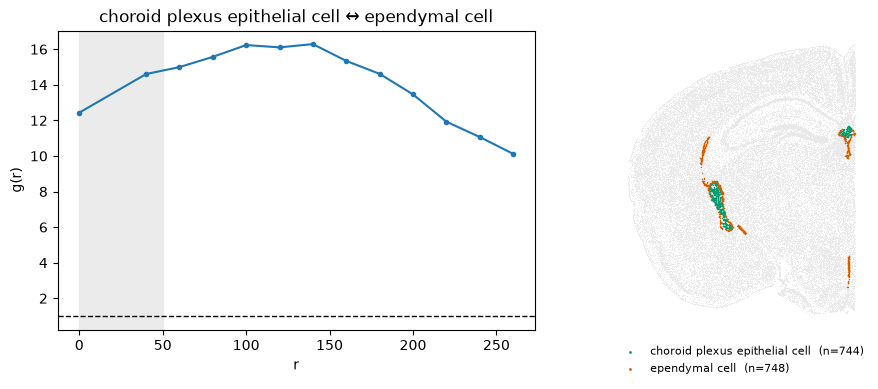

In [16]:
plot_interaction(adata, "cross_pcf", ("choroid plexus epithelial cell", "ependymal cell"), 
                 groupby=cell_type_key, 
                 spatial_key=spatial_key, 
                 max_dist=50,
                 s=1);

### Exclusion: cells occupy distinct anatomical compartments

**Choroid plexus epithelial cells** are confined to the choroid plexus at the ventricular interface, whereas **glutamatergic neurons** are distributed throughout the surrounding brain parenchyma. Their strong depletion, with `g(r)<1`, indicates fewer cross-type neighbours than expected and primarily reflects spatial compartmentalisation rather than direct cellular repulsion.

In [17]:
print(cross_pcf_res[["label", "score"]].tail(3).to_string(index=False))

                                                          label       score
          choroid plexus epithelial cell ↔ glutamatergic neuron -124.670262
               choroid plexus epithelial cell ↔ oligodendrocyte -128.319180
choroid plexus epithelial cell ↔ oligodendrocyte precursor cell -153.451459


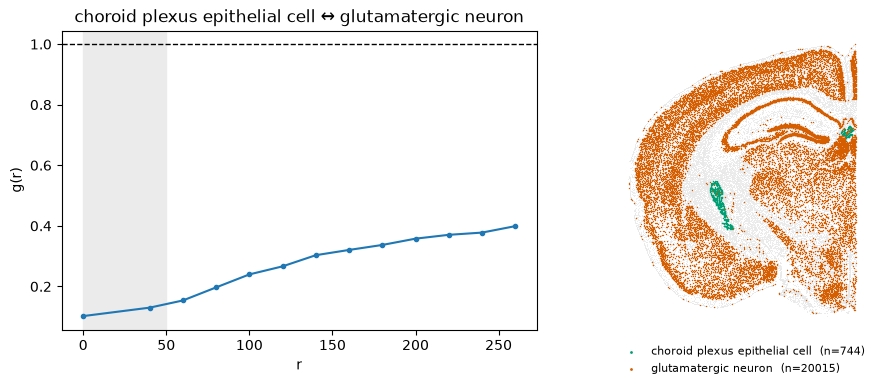

In [18]:
plot_interaction(adata, "cross_pcf", ("choroid plexus epithelial cell", "glutamatergic neuron"), 
                 groupby=cell_type_key, spatial_key=spatial_key,
                 max_dist=50, 
                 s=1);

### Landscape summary

This plot ranks 55 cell-type interactions from the most spatially enriched to the most depleted within the analysed distance range. The AUC log₂ score summarises each interaction’s cross-PCF profile: values above zero indicate spatial enrichment, values below zero indicate spatial depletion, and the dashed line marks the neutral expectation. The two highest- and two lowest-scoring interactions are highlighted and labelled.

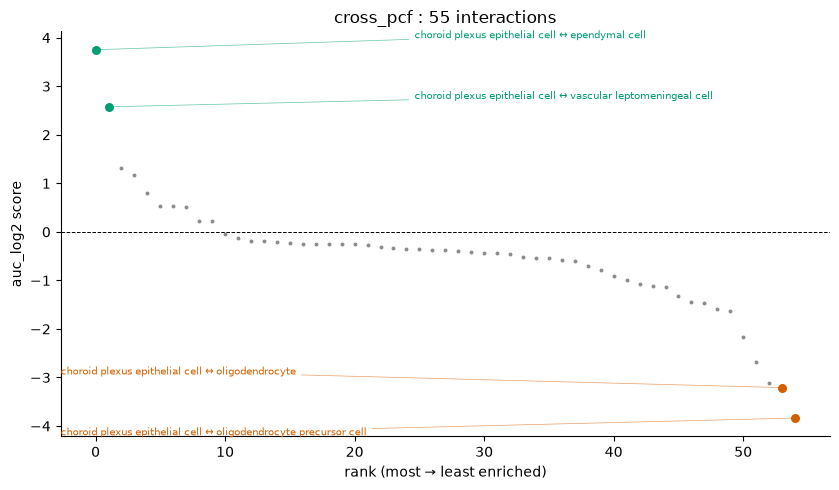

In [19]:
plot_landscape(adata, "cross_pcf", max_dist=50, min_bins= 2, top=2);

## Ligand–Receptor Global Co-expression using LRIC

The agnostic mode of LRIC answers questions like:

> Across all cells in the tissue, is the ligand signal spatially enriched around receptor-expressing receiver cells at distance r more than expected by chance?

In [20]:
li.mt.lric(
    adata,
    resource=resource,
    spatial_key=spatial_key,
    max_radius=250,
    radius_step=radius_step,
    annulus_width=annulus_width,
    expr_prop  = 0.05,  # NaN-mask ligand/receptor pairs expressed in <2% of cells
    use_raw=False,
    key_added="lric_ag",  #results will be saved under this label in adata.uns
    verbose=True,
)

Using `.X`!


Using provided `resource`.


Running cell-type-agnostic LRIC.


In [21]:
## Explore the output:
print(adata.uns["lric_ag"].keys())

dict_keys(['pair_names', 'radii', 'lric'])


### Strong short-range liagnd-receptor spatial co-enrichment

In [22]:
# short-range
lric_ag_res = auc_log2_score(adata, "lric_ag", max_dist=50, normalize=False, min_bins=2)
print(lric_ag_res[["label", "score"]].head(3))

            label      score
0    Pdyn → Oprd1  30.482102
1    Penk → Oprd1  24.856527
2  Col18a1 → Gpc4  18.325875


**Pdyn $\rightarrow$ Oprd1** shows short-range spatial co-enrichment, with $g(r)$ reaching approximately **1.8 at the shortest distance**. This means that **Pdyn- and Oprd1-expressing cells are found near each other more often than expected based on their overall expression patterns across the tissue**. The enrichment becomes weaker with distance but remains above the baseline, suggesting that the association is strongest locally and still present over a broader spatial range.

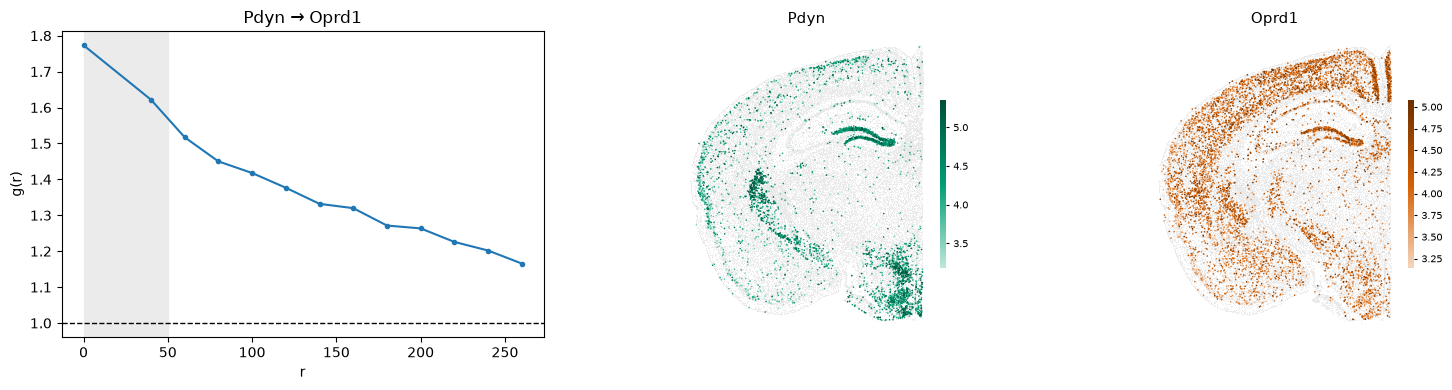

In [23]:
plot_interaction(adata, "lric_ag", "Pdyn^Oprd1",
                 spatial_key=spatial_key,
                 max_dist=50,
                 s=1);

### Strong short-range spatial depletion

In [24]:
print(lric_ag_res[["label", "score"]].tail(3))

            label      score
32    Dcn → Erbb4 -11.405328
33  Vegfc → Vipr2 -13.676652
34     Kitl → Kit -14.200827


**Dcn $\rightarrow$ Erbb4** shows short-range spatial depletion, with $g(r)$ reaching approximately **0.77 at the shortest distance** and remaining below **1 within $40\,\mu\mathrm{m}$**. This means that **Dcn- and Erbb4-expressing cells are found near each other less often than expected**.

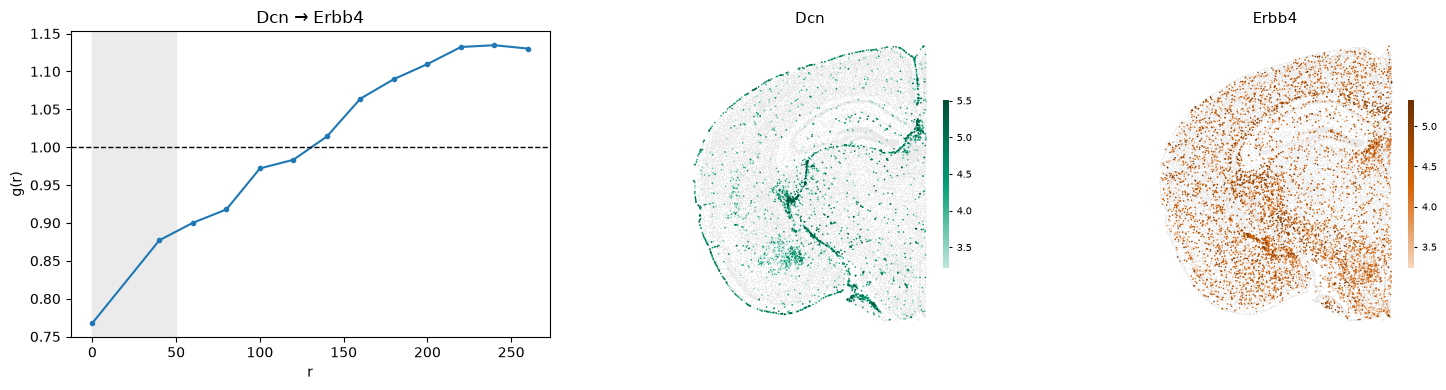

In [25]:
plot_interaction(adata, "lric_ag", "Dcn^Erbb4", 
                 spatial_key=spatial_key, 
                 max_dist=50,
                 s=1);

### Distance-resolved ligand–receptor interaction heatmap

This heatmap shows the spatial enrichment profiles of top 5 co-enriched ligand–receptor pairs across increasing distances. Each row represents one interaction, and each column represents a distance bin r. Colours encode `log2g(r)`.

Interactions that remain red across many columns show sustained co-enrichment over a broad spatial range, whereas fading towards white indicates that enrichment weakens with distance.

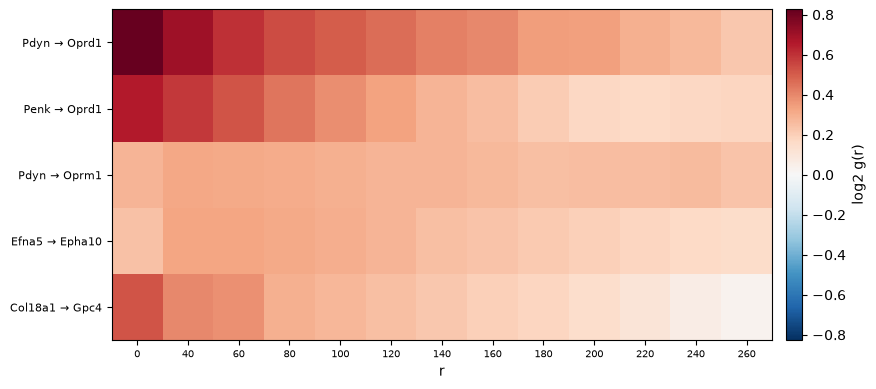

In [27]:
plot_top_heatmap(adata, "lric_ag", n=5);

## LRIC Cell-Type Informed for Directed Interactions

The **cell-type-informed** mode splits cells into sender and receiver populations by cell-type annotation and computes g(r) for every directed **(sender → receiver)** pair, weighted by the LR expression.

This answers a more specific question:

> For the specific interaction **sender cell type X expressing ligand L** → **receiver cell type Y expressing receptor R**, is the LR-weighted spatial co-enrichment at distance r higher than expected?

**Key advantage over cross-PCF**: the expression weighting means g(r) > 1 can only be driven by cells that express the relevant ligand/receptor.

In [28]:
li.mt.lric(
    adata,
    resource=resource,
    groupby=cell_type_key,
    spatial_key=spatial_key,
    max_radius=250,
    radius_step=radius_step,
    annulus_width=annulus_width,
    expr_prop=0.2,  # NaN-mask sender/receiver-celltype pairs expressed in <2% of that celltype
    use_raw=False,
    key_added="lric_ct", #results will be saved under this label in adata.uns
    verbose=True,
)

`min_cells=None`: dropping cell types with <= 1.0% of 51539 cells (min_cells=516).
Using `.X`!


The following cell identities were excluded: neuroblast (sensu Vertebrata), cholinergic neuron, smooth muscle cell, macrophage, dendritic cell, lymphocyte, monocyte, dopaminergic neuron, tanycyte, histaminergic neuron, glycinergic neuron


Using provided `resource`.


Running LRIC (conditional within-type null) for 11 cell types (110 directed pairs).
LRIC: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 110/110 [00:05<00:00, 20.76it/s]


In [29]:
# short-range interactions (max_dist=50 µm) by area under log2 g(r) curve
lric_ct_res = auc_log2_score(adata, "lric_ct", max_dist=50, normalize=False, min_bins=2)
print(lric_ct_res[["label", "score"]].head(3).to_string(index=False))

                                                                        label      score
vascular leptomeningeal cell → choroid plexus epithelial cell  Col18a1 → Gpc4 155.854481
              choroid plexus epithelial cell → ependymal cell  Sostdc1 → Lrp4 150.382026
              choroid plexus epithelial cell → ependymal cell  Col18a1 → Gpc4 149.406731


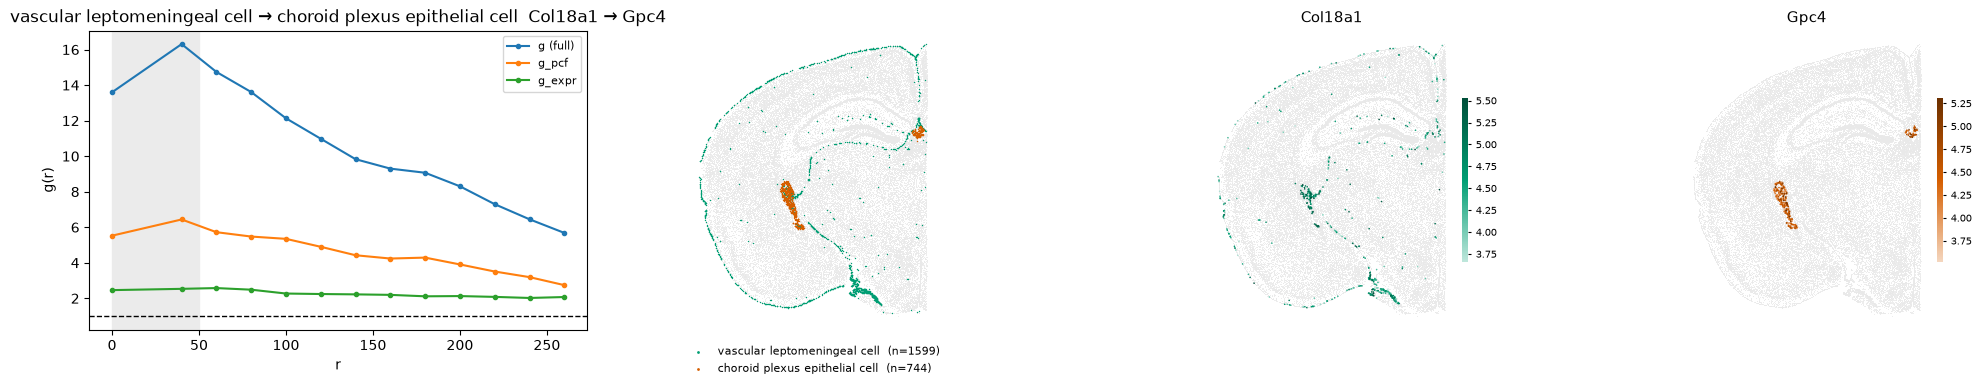

In [30]:
plot_interaction(adata, "lric_ct", (("vascular leptomeningeal cell", "choroid plexus epithelial cell"), "Col18a1^Gpc4"), 
                 groupby="cell_type", 
                 spatial_key=spatial_key, 
                 max_dist=50,
                 s=1);

**Col18a1 $\rightarrow$ Gpc4** from **vascular leptomeningeal cells $\rightarrow$ choroid plexus epithelial cells** shows the strongest cell-type-informed spatial enrichment, with $g_{\mathrm{full}}(r)$ peaking at approximately **16.3 around $40\,\mu\mathrm{m}$**.

The underlying cell-type organisation is already strongly enriched ($g_{\mathrm{pcf}} \approx 6.4$), reflecting the close spatial association of vascular leptomeningeal and choroid plexus epithelial cells. Ligand–receptor expression provides an additional enrichment component ($g_{\mathrm{expr}} \approx 2.5$), amplifying the full signal beyond that explained by cell-type proximity alone.

Thus, the interaction is supported by both anatomical co-localisation and non-random **Col18a1/Gpc4** expression within the respective sender and receiver populations.

### Landscape summary

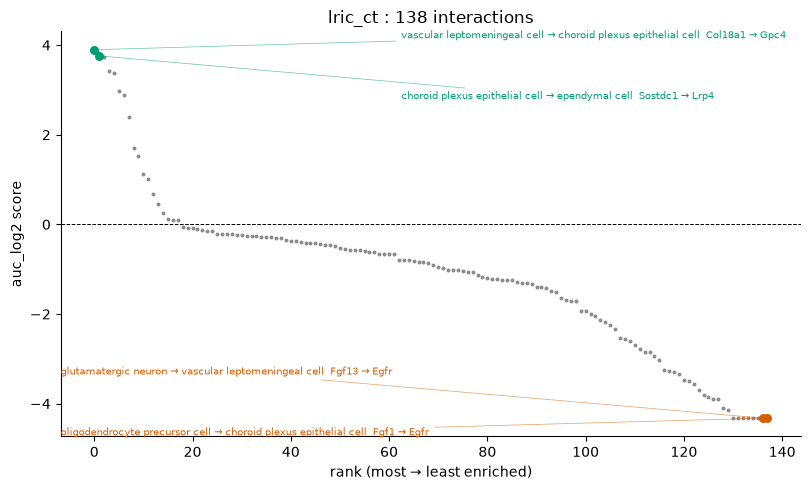

In [31]:
plot_landscape(adata, "lric_ct", max_dist=50, min_bins= 2, top=2);

---

## Comparing full interaction curves using divergence

Previously, we used AUC to collapse each interaction curve into a single number. This is simple and useful for ranking, but it discards where along radius r two curves differ. In addition, differences with opposite signs at different radii can cancel when summarized by a signed integral.
<br>
Here, we introduce a second summary score that compares the **full curves**: curve divergence.

Unlike `AUC–log2`, divergence does not describe whether an interaction is generally enriched or depleted. Instead, it answers:
> How different are these two spatial interaction profiles, and at what radius is their separation greatest?

**Read it as:** divergence `≈ 0` means the two interactions have similar spatial profiles, while a larger value means they differ more strongly across distance.


In [32]:
def _pair_data(adata, modality, fa, fb, max_dist=None, min_bins=3):
    ads = [adata] if hasattr(adata, "uns") else list(adata)
    x0, A, B = None, [], []

    def get(ad, f):
        for k, y in _iter_features(ad, modality):
            if k == f or (modality == "cross_pcf" and frozenset(k) == frozenset(f)):
                return _log2g(y)
        raise KeyError(f"{f!r} not found in {modality!r}")

    for ad in ads:
        r = np.asarray(ad.uns[modality]["radii"], float)
        if x0 is not None and not np.allclose(r, x0): raise ValueError("Radii differ between samples.")
        x0 = r; A.append(get(ad, fa)); B.append(get(ad, fb))

    x, A, B = x0 + HALF_ANNULUS, np.vstack(A), np.vstack(B)
    keep = np.isfinite(x) & np.isfinite(A).all(0) & np.isfinite(B).all(0)
    if max_dist is not None: keep &= x0 < max_dist
    if keep.sum() < min_bins: raise ValueError(f"Only {keep.sum()} shared finite bins.")
    return x[keep], A[:, keep], B[:, keep]


def divergence_log2_test(adata, modality, feature_a, feature_b, *,
                         max_dist=None, normalize=True, min_bins=3,
                         max_perm=2000, seed=0):
    """Area between two mean log2 g(r) curves; paired sign-flip p-value."""
    x, A, B = _pair_data(adata, modality, feature_a, feature_b, max_dist, min_bins)
    D = A - B; d = D.mean(0); span = x[-1] - x[0]
    scale = span if normalize and span > 0 else 1
    T = np.trapezoid(abs(d), x) / scale
    j, n = np.argmax(abs(d)), len(D)

    p, nperm = np.nan, 0
    if n > 1:
        exact = 2**n <= max_perm
        S = (np.array(list(itertools.product((-1, 1), repeat=n))) if exact else
             np.random.default_rng(seed).choice((-1, 1), (max_perm, n)))
        Tp = np.trapezoid(abs(S @ D / n), x, axis=1) / scale
        nperm = len(Tp); hits = (Tp >= T * (1 - 1e-12)).sum()
        p = hits / nperm if exact else (hits + 1) / (nperm + 1)

    return pd.Series({
        "modality": modality, "feature_a": feature_a, "feature_b": feature_b,
        "label_a": _feature_label(feature_a, modality).replace("\n", "  "),
        "label_b": _feature_label(feature_b, modality).replace("\n", "  "),
        "divergence": T, "r_star": x[j], "delta_star": d[j],
        "direction": "A > B" if d[j] > 0 else "B > A" if d[j] < 0 else "equal",
        "p": p, "n_samples": n, "n_perm": nperm,
        "max_dist": max_dist, "normalize": normalize, "min_bins": min_bins
    })


def plot_pair_divergence(adata, res, figsize=(7, 4.5)):
    x, A, B = _pair_data(adata, res.modality, res.feature_a, res.feature_b,
                         res.max_dist, res.min_bins)
    ma, mb = A.mean(0), B.mean(0)
    fig, ax = plt.subplots(figsize=figsize)

    ax.fill_between(x, ma, mb, color="0.6", alpha=.35, lw=0, label="divergence")
    for M, mu, col, lab in ((A, ma, C_TOP, res.label_a), (B, mb, C_BOT, res.label_b)):
        sd = M.std(0)
        ax.fill_between(x, mu-sd, mu+sd, color=col, alpha=.15, lw=0)
        ax.plot(x, mu, color=col, lw=2, label=f"{lab} (mean ± SD)")

    ax.axvline(res.r_star, color="black", ls=":", lw=1)
    ax.axhline(0, color="grey", ls="--", lw=.8)
    p = f"  p={res.p:.2g}" if np.isfinite(res.p) else ""
    ax.set(title=f"{res.modality}: div={res.divergence:.3g}  "
                 f"r*={res.r_star:.0f} µm",
           xlabel="radius r (µm)", ylabel="log2 g(r)")
    ax.legend(frameon=False, fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)
    fig.tight_layout()
    return fig

### CrossPCF

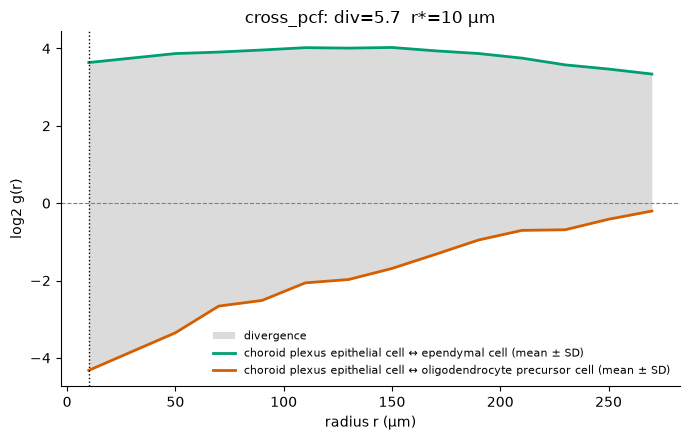

In [33]:
res = divergence_log2_test(
    adata,
    "cross_pcf",
    ("choroid plexus epithelial cell", "ependymal cell"),
    ("choroid plexus epithelial cell", "oligodendrocyte precursor cell"),
)

plot_pair_divergence(adata, res);

### agnostic LRIC

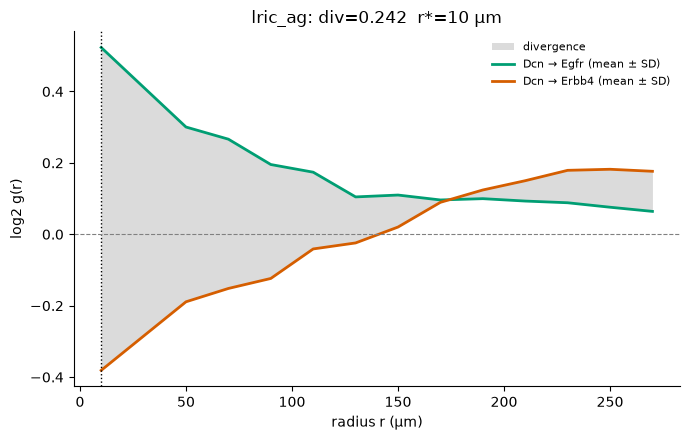

In [34]:
res = divergence_log2_test(
    adata, "lric_ag",
    "Dcn^Egfr", "Dcn^Erbb4"
)
plot_pair_divergence(adata, res);

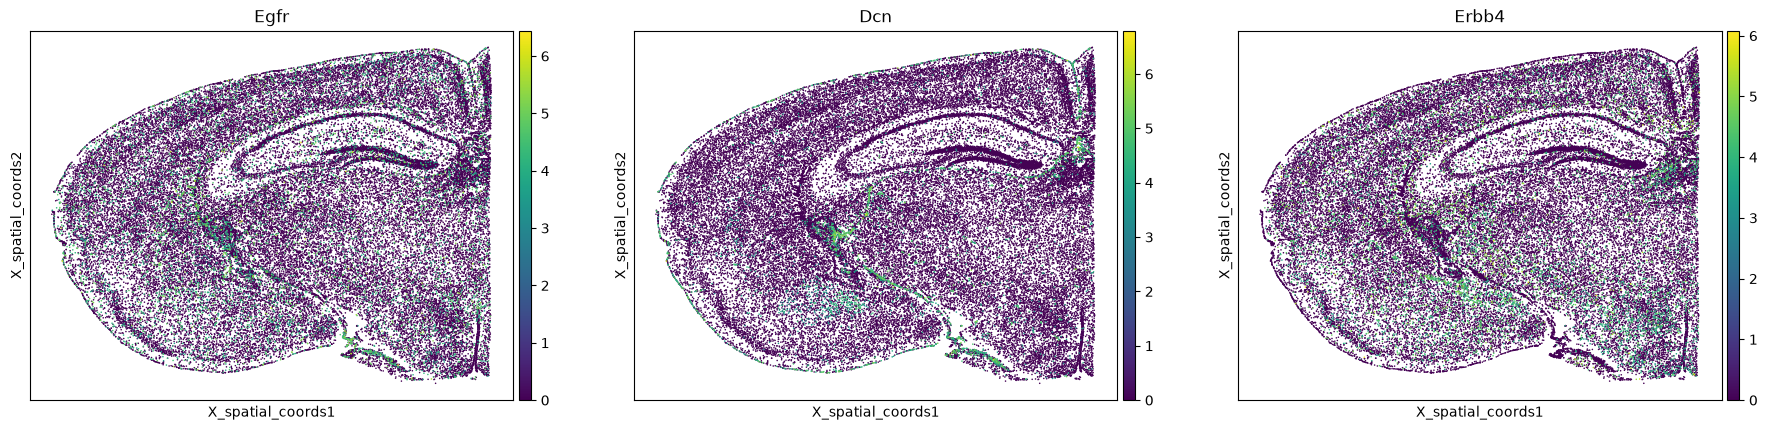

In [35]:
sc.pl.embedding(
    adata,
    basis=spatial_key,
    color=["Egfr", "Dcn", "Erbb4"],
    s=5,
    use_raw=False
)

### CT-informed LRIC

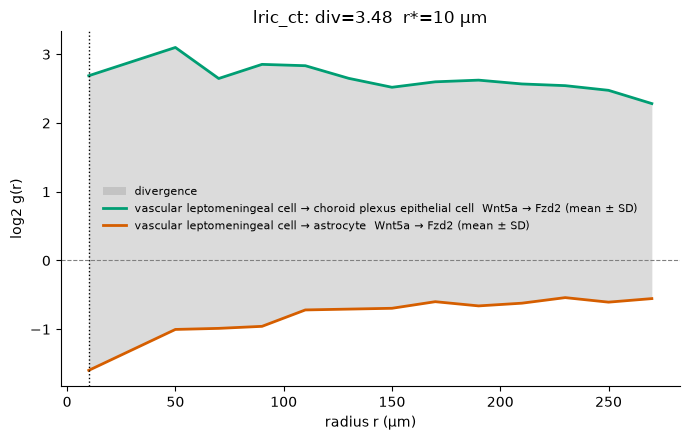

In [37]:
res = divergence_log2_test(
    adata, "lric_ct",
    (("vascular leptomeningeal cell",
      "choroid plexus epithelial cell"), "Wnt5a^Fzd2"),
    (("vascular leptomeningeal cell",
      "astrocyte"), "Wnt5a^Fzd2")
)

plot_pair_divergence(adata, res);

---

<div style="border:2px solid #790e0eff; background-color:#e3f2fd; padding:12px; border-radius:8px; font-size:1.1em; margin:10px 0;">
<strong>Note:</strong> This tutorial is part of an ongoing <b>LIANA+</b> extension (Alsayah et al., in prep). Feedback welcome!
</div>